# Neuron overlap analysis: original vs ASDiv localizer

Compares reward-sensitive MLP neurons identified from two localizer datasets:
- **Original** — geo + math simple arithmetic (cross-domain 3σ)
- **ASDiv** — word problems from ASDiv (single-domain 3σ, money ∩ reward)

Key question: do the two localizers identify the same neurons, or does the
original set capture simple-arithmetic surface features rather than abstract
reward processing?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from matplotlib_venn import venn2
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'font.family': 'sans-serif',
})


## 1. Load neuron sets

In [2]:
files = {
    'orig_core':    '/mnt/upschrimpf2/scratch/mahdipou/models/Anhedonic-AI/Experiment1/phase4/extraction/master_incentive_core.csv',
    'orig_money':   '/mnt/upschrimpf2/scratch/mahdipou/models/Anhedonic-AI/Experiment1/phase4/extraction/universal_money_neurons.csv',
    'orig_reward':  '/mnt/upschrimpf2/scratch/mahdipou/models/Anhedonic-AI/Experiment1/phase4/extraction/universal_reward_neurons.csv',
    'asdiv_core':   'asdiv_master_incentive_core.csv',
    'asdiv_money':  'asdiv_universal_money_neurons.csv',
    'asdiv_reward': 'asdiv_universal_reward_neurons.csv',
}

dfs = {k: pd.read_csv(v) for k, v in files.items()}
sets = {k: set(zip(df['layer'], df['neuron'])) for k, df in dfs.items()}

orig_core   = sets['orig_core']
asdiv_core  = sets['asdiv_core']
orig_money  = sets['orig_money']
asdiv_money = sets['asdiv_money']
orig_reward = sets['orig_reward']
asdiv_reward= sets['asdiv_reward']

inter_core   = orig_core  & asdiv_core
inter_money  = orig_money & asdiv_money
inter_reward = orig_reward & asdiv_reward

def jaccard(a, b): return len(a & b) / len(a | b) if (a | b) else 0.0
def recall(a, b):  return len(a & b) / len(a) if a else 0.0      # how much of a is in b
def precision(a, b): return len(a & b) / len(b) if b else 0.0    # how much of b was in a

summary = pd.DataFrame([
    {
        'Set':           'Core (money ∩ reward)',
        'Original':      len(orig_core),
        'ASDiv':         len(asdiv_core),
        'Overlap':       len(inter_core),
        'Jaccard':       round(jaccard(orig_core, asdiv_core), 4),
        'Recall (orig)': round(recall(orig_core, asdiv_core), 4),
        'Precision':     round(precision(orig_core, asdiv_core), 4),
    },
    {
        'Set':           'Money neurons',
        'Original':      len(orig_money),
        'ASDiv':         len(asdiv_money),
        'Overlap':       len(inter_money),
        'Jaccard':       round(jaccard(orig_money, asdiv_money), 4),
        'Recall (orig)': round(recall(orig_money, asdiv_money), 4),
        'Precision':     round(precision(orig_money, asdiv_money), 4),
    },
    {
        'Set':           'Reward neurons',
        'Original':      len(orig_reward),
        'ASDiv':         len(asdiv_reward),
        'Overlap':       len(inter_reward),
        'Jaccard':       round(jaccard(orig_reward, asdiv_reward), 4),
        'Recall (orig)': round(recall(orig_reward, asdiv_reward), 4),
        'Precision':     round(precision(orig_reward, asdiv_reward), 4),
    },
])

print(summary.to_string(index=False))


                  Set  Original  ASDiv  Overlap  Jaccard  Recall (orig)  Precision
Core (money ∩ reward)      3528   7913      708   0.0660         0.2007     0.0895
        Money neurons      5467  12302     1524   0.0938         0.2788     0.1239
       Reward neurons      5558  11517     1377   0.0877         0.2478     0.1196


## 2. Overlap overview

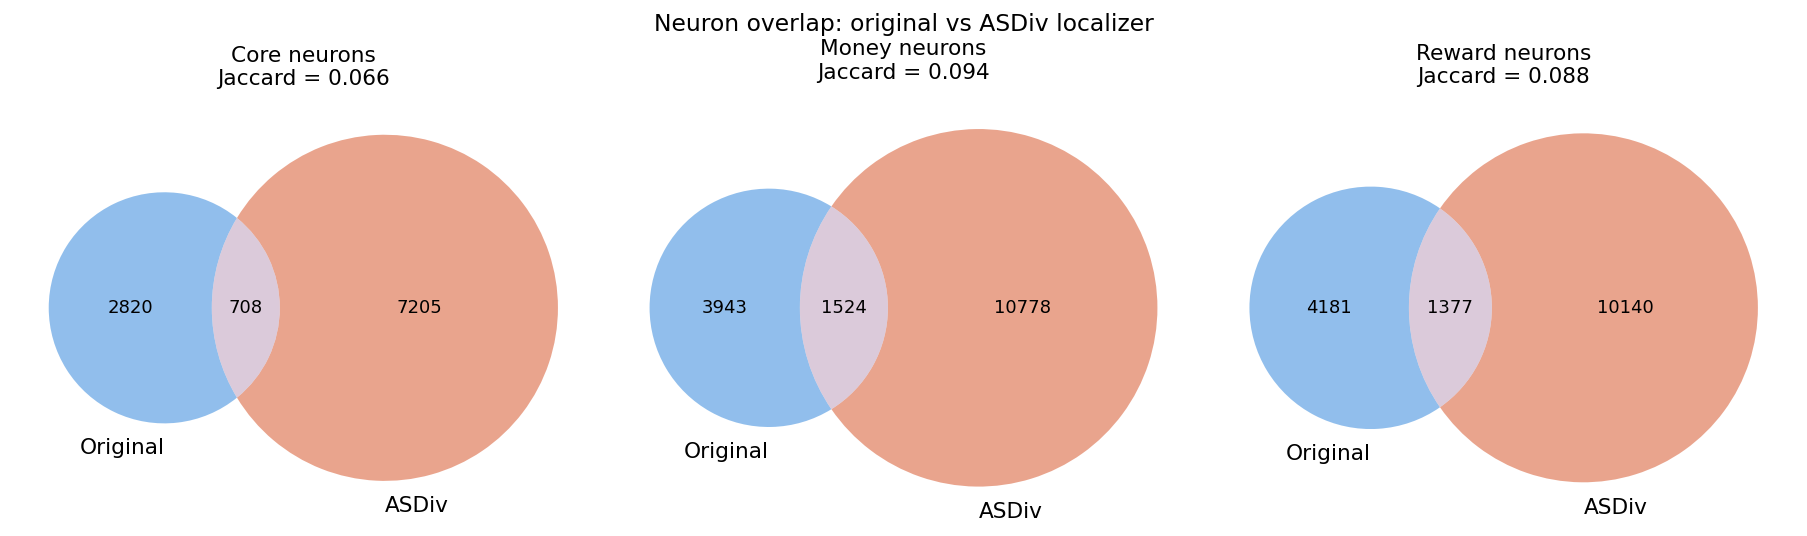

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

pairs = [
    ('Core', orig_core, asdiv_core, inter_core),
    ('Money', orig_money, asdiv_money, inter_money),
    ('Reward', orig_reward, asdiv_reward, inter_reward),
]

for ax, (label, orig, asdiv, inter) in zip(axes, pairs):
    orig_only  = len(orig)  - len(inter)
    asdiv_only = len(asdiv) - len(inter)
    shared     = len(inter)
    v = venn2(
        subsets=(orig_only, asdiv_only, shared),
        set_labels=('Original', 'ASDiv'),
        set_colors=('#378ADD', '#D85A30'),
        alpha=0.55,
        ax=ax,
    )
    ax.set_title(f'{label} neurons\nJaccard = {jaccard(orig, asdiv):.3f}', pad=8)

plt.suptitle('Neuron overlap: original vs ASDiv localizer', y=1.02, fontsize=13, fontweight='500')
plt.tight_layout()
plt.show()


## 3. Per-layer neuron counts

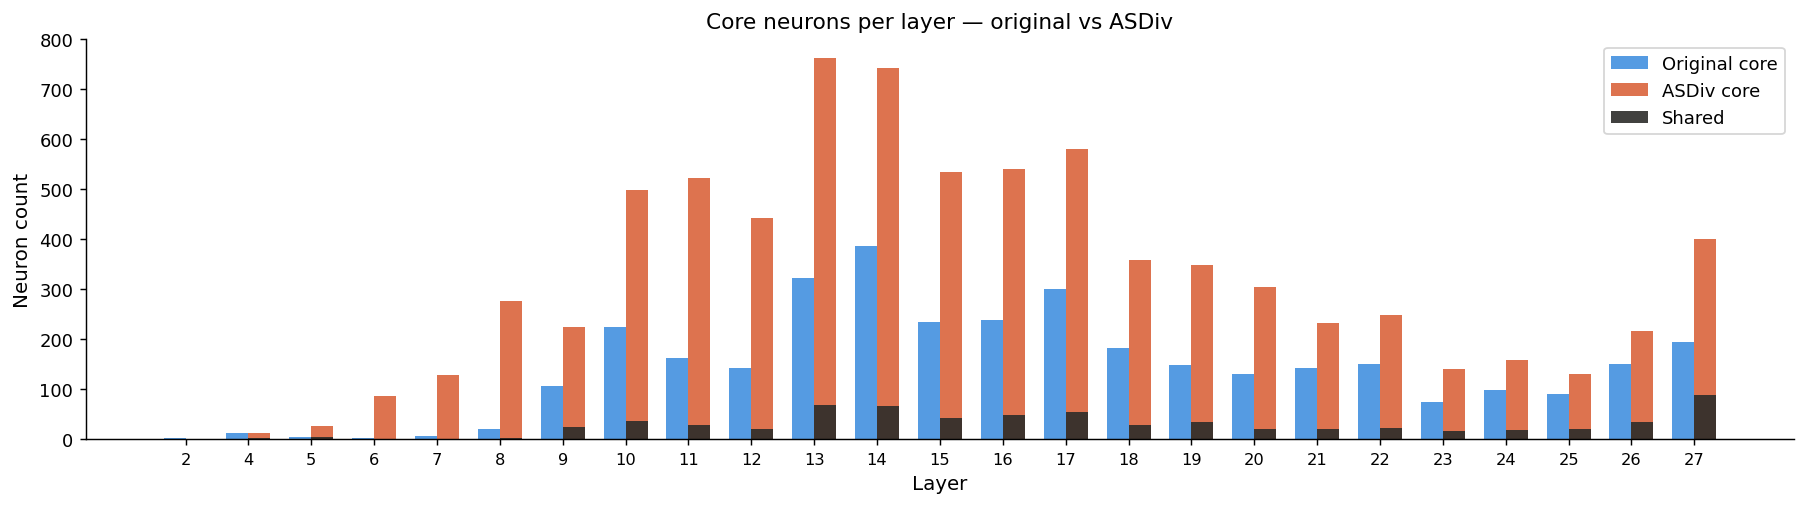

In [5]:
all_layers = sorted(set(l for l, n in orig_core | asdiv_core))

orig_counts  = [sum(1 for l, n in orig_core  if l == layer) for layer in all_layers]
asdiv_counts = [sum(1 for l, n in asdiv_core if l == layer) for layer in all_layers]
inter_counts = [sum(1 for l, n in inter_core if l == layer) for layer in all_layers]

x = np.arange(len(all_layers))
w = 0.35

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(x - w/2, orig_counts,  w, label='Original core', color='#378ADD', alpha=0.85)
ax.bar(x + w/2, asdiv_counts, w, label='ASDiv core',    color='#D85A30', alpha=0.85)
ax.bar(x + w/2, inter_counts, w, label='Shared',        color='#2C2C2A', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(all_layers, fontsize=9)
ax.set_xlabel('Layer')
ax.set_ylabel('Neuron count')
ax.set_title('Core neurons per layer — original vs ASDiv')
ax.legend()
plt.tight_layout()
plt.show()


## 4. Per-layer recall — how much of original is recovered by ASDiv?

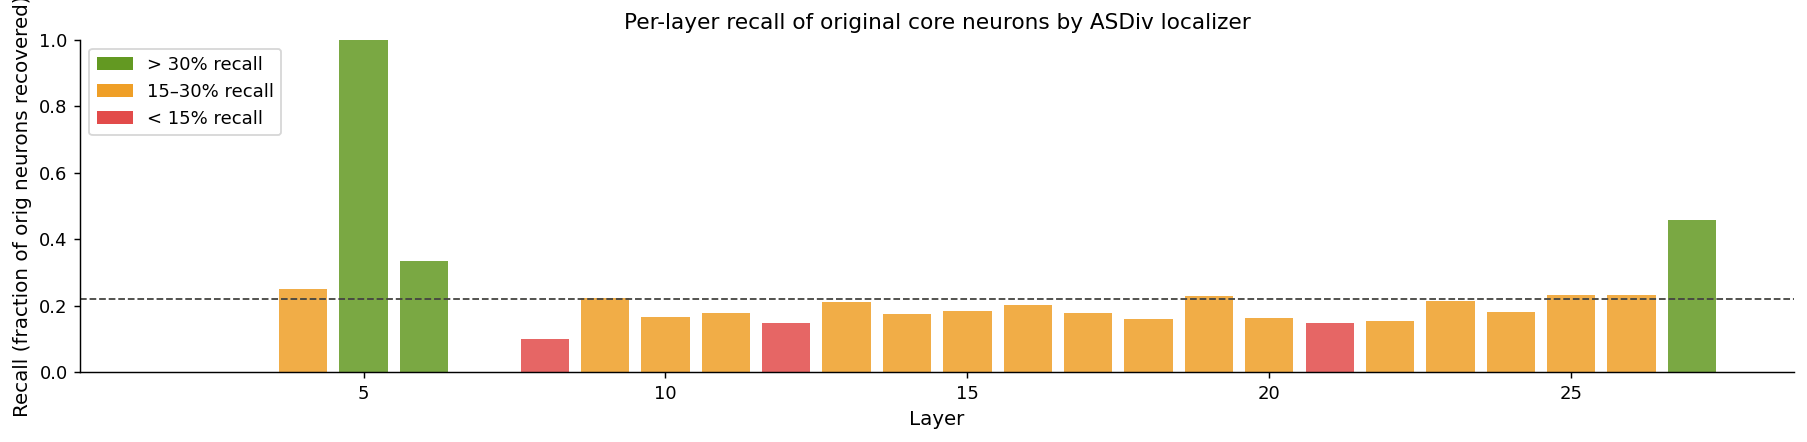

In [6]:
layer_recall = []
for layer in all_layers:
    o = [(l, n) for l, n in orig_core  if l == layer]
    b = [(l, n) for l, n in inter_core if l == layer]
    layer_recall.append(len(b) / len(o) if o else 0)

fig, ax = plt.subplots(figsize=(14, 3.5))
colors = ['#639922' if r > 0.3 else '#EF9F27' if r > 0.15 else '#E24B4A'
          for r in layer_recall]
ax.bar(all_layers, layer_recall, color=colors, alpha=0.85)
ax.axhline(np.mean(layer_recall), color='#444441', linestyle='--', linewidth=1,
           label=f'Mean recall = {np.mean(layer_recall):.2f}')
ax.set_xlabel('Layer')
ax.set_ylabel('Recall (fraction of orig neurons recovered)')
ax.set_title('Per-layer recall of original core neurons by ASDiv localizer')
ax.set_ylim(0, 1)
ax.legend()

legend_elements = [
    Patch(facecolor='#639922', label='> 30% recall'),
    Patch(facecolor='#EF9F27', label='15–30% recall'),
    Patch(facecolor='#E24B4A', label='< 15% recall'),
]
ax.legend(handles=legend_elements, loc='upper left')
plt.tight_layout()
plt.show()


## 5. Neuron index distribution (which neurons in the MLP are activated?)

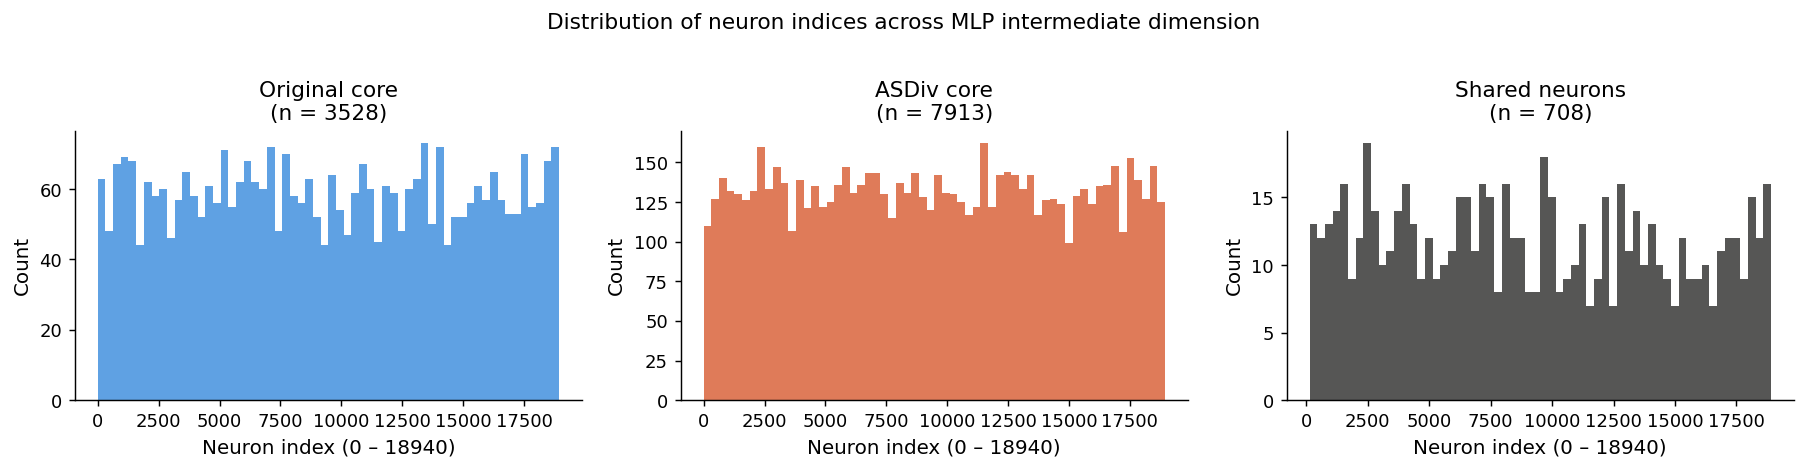

In [7]:
orig_neurons  = [n for l, n in orig_core]
asdiv_neurons = [n for l, n in asdiv_core]
shared_neurons= [n for l, n in inter_core]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), sharey=False)

for ax, data, label, color in zip(
    axes,
    [orig_neurons, asdiv_neurons, shared_neurons],
    ['Original core', 'ASDiv core', 'Shared neurons'],
    ['#378ADD', '#D85A30', '#2C2C2A'],
):
    ax.hist(data, bins=60, color=color, alpha=0.8, edgecolor='none')
    ax.set_xlabel('Neuron index (0 – 18940)')
    ax.set_ylabel('Count')
    ax.set_title(f'{label}\n(n = {len(data)})')

plt.suptitle('Distribution of neuron indices across MLP intermediate dimension',
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()


## 6. Exclusive neurons — what does each localizer uniquely identify?

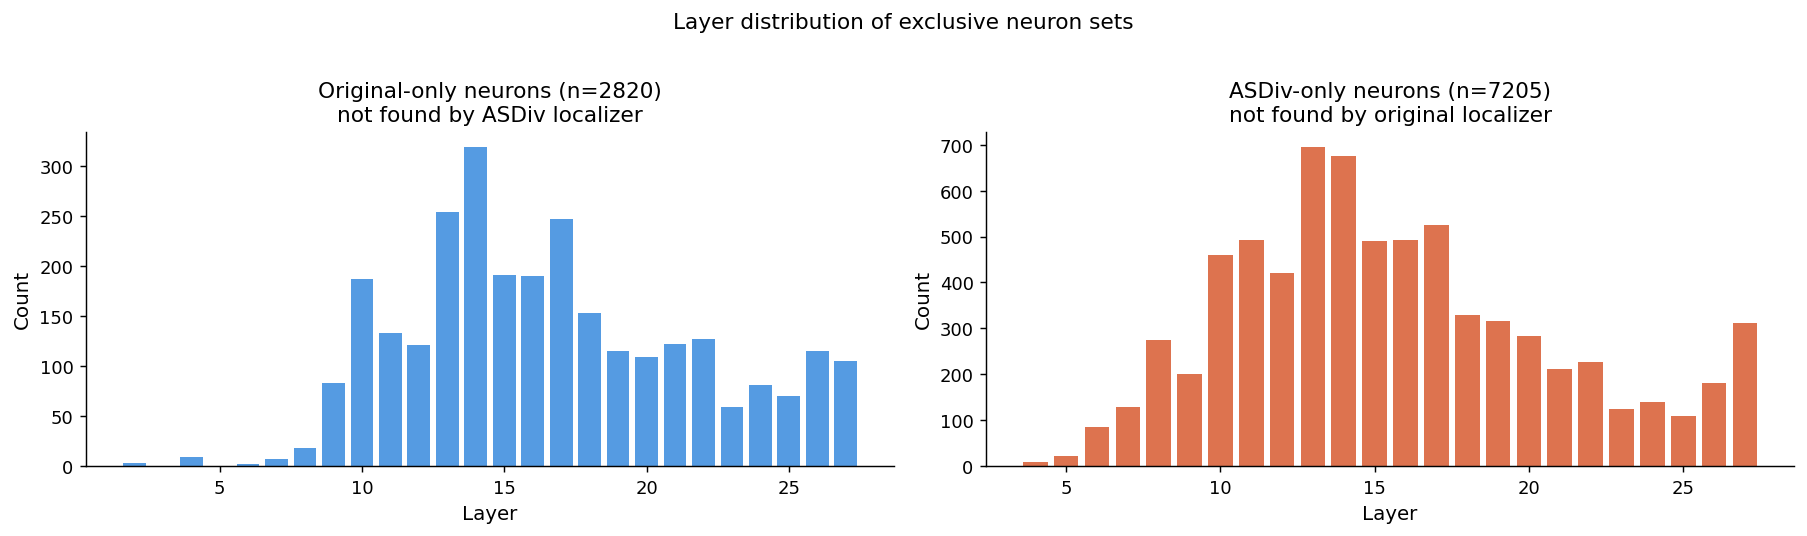

Original-only:  2,820 neurons  (79.9% of original core)
ASDiv-only:     7,205 neurons  (91.1% of ASDiv core)
Shared:         708 neurons


In [8]:
orig_only_set  = orig_core - asdiv_core
asdiv_only_set = asdiv_core - orig_core

# Layer distribution of exclusive sets
orig_excl_by_layer  = pd.Series([l for l, n in orig_only_set]).value_counts().sort_index()
asdiv_excl_by_layer = pd.Series([l for l, n in asdiv_only_set]).value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(orig_excl_by_layer.index, orig_excl_by_layer.values, color='#378ADD', alpha=0.85)
axes[0].set_title(f'Original-only neurons (n={len(orig_only_set)})\nnot found by ASDiv localizer')
axes[0].set_xlabel('Layer')
axes[0].set_ylabel('Count')

axes[1].bar(asdiv_excl_by_layer.index, asdiv_excl_by_layer.values, color='#D85A30', alpha=0.85)
axes[1].set_title(f'ASDiv-only neurons (n={len(asdiv_only_set)})\nnot found by original localizer')
axes[1].set_xlabel('Layer')
axes[1].set_ylabel('Count')

plt.suptitle('Layer distribution of exclusive neuron sets', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

print(f'Original-only:  {len(orig_only_set):,} neurons  '
      f'({len(orig_only_set)/len(orig_core)*100:.1f}% of original core)')
print(f'ASDiv-only:     {len(asdiv_only_set):,} neurons  '
      f'({len(asdiv_only_set)/len(asdiv_core)*100:.1f}% of ASDiv core)')
print(f'Shared:         {len(inter_core):,} neurons')


## 7. Neuron presence heatmap — layer × index bucket

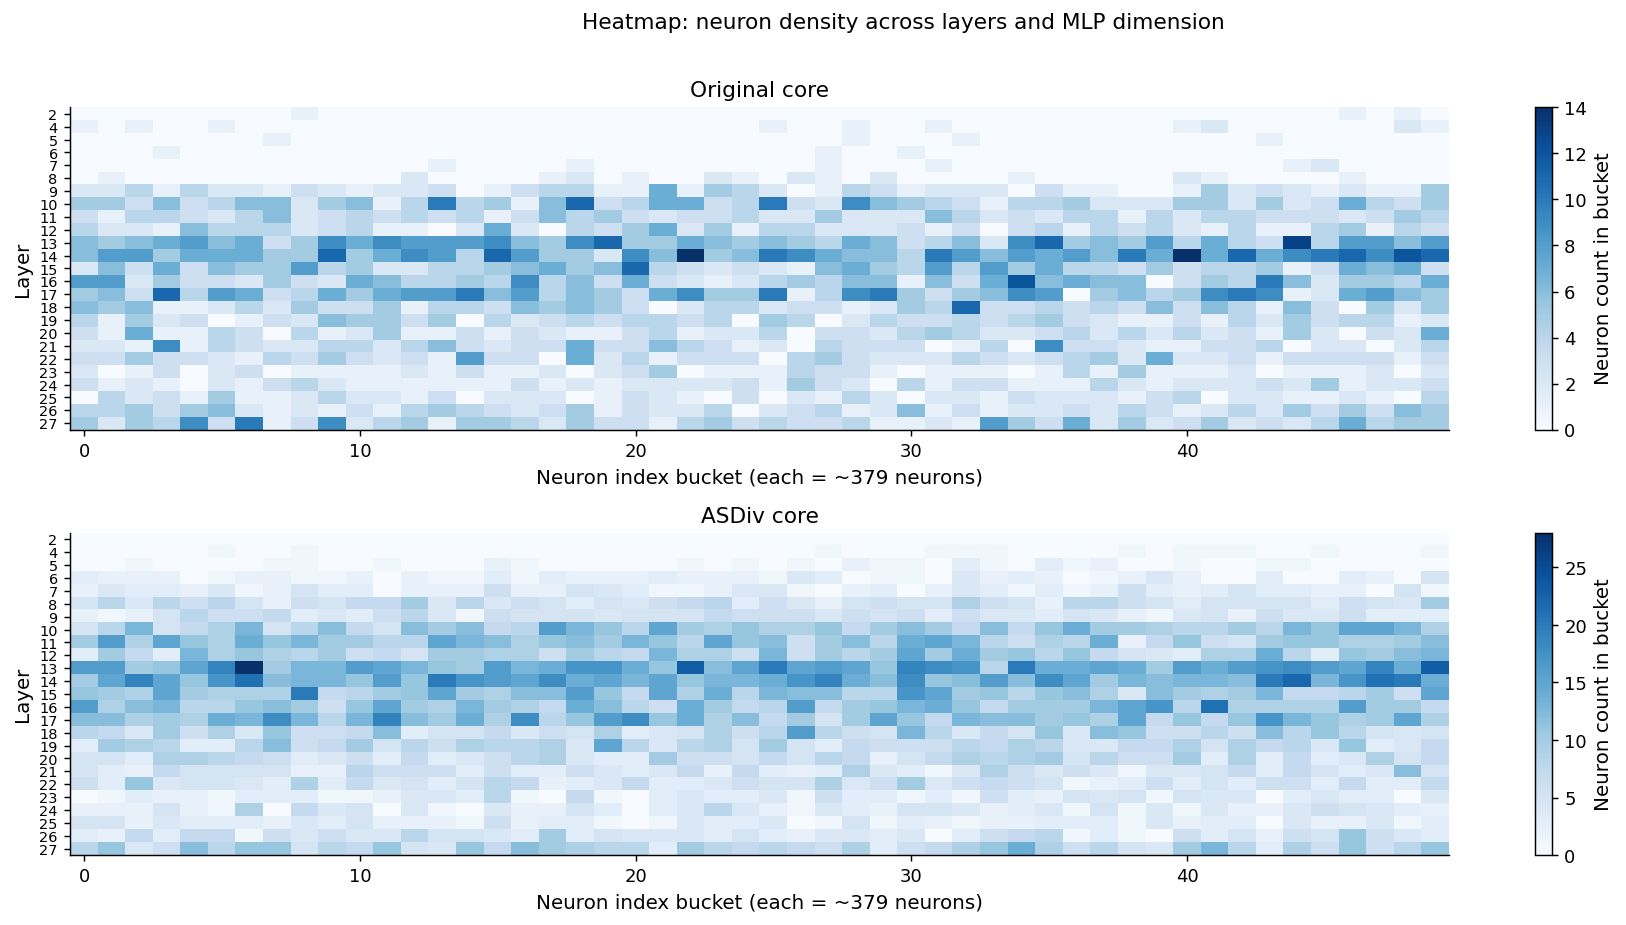

In [9]:
# Bin neuron indices into 50 buckets for visualisation
n_buckets = 50
max_neuron = 18940
bucket_size = max_neuron // n_buckets

def make_heatmap(neuron_set, layers, n_buckets, bucket_size):
    mat = np.zeros((len(layers), n_buckets))
    layer_idx = {l: i for i, l in enumerate(layers)}
    for l, n in neuron_set:
        if l in layer_idx:
            b = min(n // bucket_size, n_buckets - 1)
            mat[layer_idx[l], b] += 1
    return mat

layers = all_layers
mat_orig  = make_heatmap(orig_core,  layers, n_buckets, bucket_size)
mat_asdiv = make_heatmap(asdiv_core, layers, n_buckets, bucket_size)

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

for ax, mat, title in zip(
    axes,
    [mat_orig, mat_asdiv],
    ['Original core', 'ASDiv core'],
):
    im = ax.imshow(mat, aspect='auto', cmap='Blues', interpolation='nearest')
    ax.set_yticks(range(len(layers)))
    ax.set_yticklabels(layers, fontsize=8)
    ax.set_xlabel('Neuron index bucket (each = ~379 neurons)')
    ax.set_ylabel('Layer')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label='Neuron count in bucket')

plt.suptitle('Heatmap: neuron density across layers and MLP dimension',
             y=1.01, fontsize=12)
plt.tight_layout()
plt.show()


## 8. Interpretation

### Key numbers
| Metric | Value |
|---|---|
| Original core | 3,528 neurons |
| ASDiv core | 7,913 neurons |
| Shared | 708 neurons |
| Jaccard (core) | **0.066** |
| Recall of original | 20.1% |
| Precision of ASDiv | 8.9% |

### What this means

**Jaccard of 0.066 is low** — the two localizers identify largely non-overlapping neuron sets.
Only ~20% of the original core neurons appear in the ASDiv core, and only ~9% of the ASDiv
core was in the original.

**Two interpretations to consider:**

1. **The original neurons captured simple-arithmetic surface features.** The geo+math datasets
   used short, formulaic prompts (`What is 45 + 10?`). The 3σ threshold may have locked onto
   neurons that encode simple number-crunching rather than abstract reward processing. ASDiv
   word problems activate a broader, different set of neurons.

2. **ASDiv's single-domain localizer is noisier.** The original used a cross-domain
   intersection (geo ∩ math) which acts as an implicit noise filter — only neurons
   significant in *both* domains survive. ASDiv applied 3σ on a single domain, so more
   false positives pass through (ASDiv core is 2.2× larger).

**The shared 708 neurons (layer 27 most prominent with 89 shared) are the strongest
candidates for genuinely abstract reward-sensitive neurons** — they survive both a
cross-domain filter and a question-complexity change.

### Recommended next steps
- **Option A (conservative):** Ablate only the 708 shared neurons as `model_B` — these are
  the highest-confidence reward neurons. Compare baseline vs model_A (3528) vs model_B (708).
- **Option B (full replication):** Ablate the full ASDiv core (7913) as `model_B` and compare
  behavioural shift against model_A. If ASDiv neurons produce a larger behavioural effect,
  they are likely capturing more reward signal.
- **Report to supervisor:** The low overlap is itself a finding — it suggests the choice of
  localizer dataset matters and that future work should use harder, naturalistic problems
  (like ASDiv) for neuron identification.


## 9. Export shared neurons as ablation-ready JSON

In [10]:
import json
from collections import defaultdict

# Shared (highest confidence) neuron set
shared_map = defaultdict(list)
for layer, neuron in sorted(inter_core):
    shared_map[layer].append(neuron)

with open('neurons_shared.json', 'w') as f:
    json.dump({str(k): v for k, v in shared_map.items()}, f, indent=2)

# Full ASDiv core
asdiv_map = defaultdict(list)
for layer, neuron in sorted(asdiv_core):
    asdiv_map[layer].append(neuron)

with open('neurons_asdiv.json', 'w') as f:
    json.dump({str(k): v for k, v in asdiv_map.items()}, f, indent=2)

print(f'neurons_shared.json — {len(inter_core)} neurons across {len(shared_map)} layers')
print(f'neurons_asdiv.json  — {len(asdiv_core)} neurons across {len(asdiv_map)} layers')
print()
print('Add these to eval.py TIERS to run model_B:')
print('  TIERS = [')
print('      ("baseline",     None),')
print('      ("model_A",      "neurons_A.json"),      # original 3528 neurons')
print('      ("model_shared", "neurons_shared.json"), # 708 shared high-confidence')
print('      ("model_asdiv",  "neurons_asdiv.json"),  # full ASDiv 7913 neurons')
print('  ]')


neurons_shared.json — 708 neurons across 23 layers
neurons_asdiv.json  — 7913 neurons across 24 layers

Add these to eval.py TIERS to run model_B:
  TIERS = [
      ("baseline",     None),
      ("model_A",      "neurons_A.json"),      # original 3528 neurons
      ("model_shared", "neurons_shared.json"), # 708 shared high-confidence
      ("model_asdiv",  "neurons_asdiv.json"),  # full ASDiv 7913 neurons
  ]
